# OtoMetrik — EDA & Preprocessing

Faz 8: `data/output/train_dataset.csv` (train), `data/output/cars1_normalized.csv` (validation),
`data/output/arabam_test_val_normalized.csv` (canlı test, şu an 20 kayıt) kaynaklarının keşifsel analizi.

## Madde 1 — Temel istatistikler & eksik değer haritası

Her kaynağın boyutu, kolon tipleri, sayısal alan özetleri ve eksik değer oranları.

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

DATA_DIR = os.path.join('..', '..', 'data', 'output')

SOURCES = {
    'train_dataset': pd.read_csv(os.path.join(DATA_DIR, 'train_dataset.csv'), low_memory=False),
    'cars1_validation': pd.read_csv(os.path.join(DATA_DIR, 'cars1_normalized.csv'), low_memory=False),
    'arabam_test': pd.read_csv(os.path.join(DATA_DIR, 'arabam_test_val_normalized.csv'), low_memory=False),
}

for name, df in SOURCES.items():
    print(f'{name}: {df.shape[0]} satir, {df.shape[1]} kolon')

train_dataset: 53205 satir, 17 kolon
cars1_validation: 53514 satir, 18 kolon
arabam_test: 20 satir, 17 kolon


In [2]:
for name, df in SOURCES.items():
    print(f'=== {name}: dtype + eksik deger % ===')
    summary = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'eksik_%': (df.isna().mean() * 100).round(1),
    })
    display(summary)

=== train_dataset: dtype + eksik deger % ===


,dtype,eksik_%
ilan_id,str,0.0
arac_turu,float64,100.0
marka,str,0.3
model,str,0.3
paket,str,0.6
kasa_turu,str,0.5
renk,str,0.3
motor_hacmi,float64,3.2
motor_gucu,float64,3.2
yil,float64,0.3


=== cars1_validation: dtype + eksik deger % ===


,dtype,eksik_%
konum,str,0.0
fiyat,float64,0.0
marka,str,0.0
seri,str,0.0
model,str,0.0
yil,int64,0.0
kilometre,float64,0.0
vites_tipi,str,0.0
yakit_tipi,str,0.0
kasa_tipi,str,0.1


=== arabam_test: dtype + eksik deger % ===


,dtype,eksik_%
ilan_id,int64,0.0
arac_turu,str,0.0
marka,str,0.0
model,str,0.0
paket,str,5.0
kasa_turu,str,0.0
renk,str,0.0
motor_hacmi,float64,0.0
motor_gucu,float64,0.0
yil,int64,0.0


In [3]:
for name, df in SOURCES.items():
    print(f'=== {name}: sayisal alan ozeti ===')
    display(df.describe())

=== train_dataset: sayisal alan ozeti ===


,arac_turu,motor_hacmi,motor_gucu,yil,kilometre,degisen_sayisi,boyali_sayisi,fiyat
count,0.0,51516.000000,51487.000000,53047.000000,5.304700e+04,42296.000000,42296.000000,5.304700e+04
mean,NaN,1527.967068,115.136636,2010.437178,2.006868e+05,0.560620,2.422853,9.653328e+05
std,NaN,352.561308,53.332635,8.517997,7.414977e+05,0.937314,3.072702,6.495963e+06
min,NaN,600.000000,25.000000,1951.000000,0.000000e+00,0.000000,0.000000,1.000000e+04
25%,NaN,1368.000000,88.000000,2005.000000,1.150000e+05,0.000000,0.000000,3.650000e+05
50%,NaN,1500.000000,105.000000,2012.000000,1.880000e+05,0.000000,1.000000,6.150000e+05
75%,NaN,1596.000000,125.000000,2017.000000,2.550000e+05,1.000000,4.000000,1.029950e+06
max,NaN,7011.000000,1000.000000,2025.000000,9.000000e+07,10.000000,12.000000,5.950000e+08


=== cars1_validation: sayisal alan ozeti ===


,fiyat,yil,kilometre,motor_hacmi,motor_gucu,ortalama_yakit_tuketimi,yakit_deposu,tramer,degisen,boyali
count,5.351400e+04,53514.000000,5.351400e+04,53496.000000,53428.000000,53514.000000,53514.000000,5.351400e+04,53514.000000,53514.000000
mean,7.632365e+05,2011.184849,2.026344e+05,1455.893487,103.542150,5.678094,52.364465,3.434185e+04,0.450779,1.906436
std,4.714006e+05,7.191565,2.846441e+05,234.298465,28.804749,1.356454,7.921370,8.285871e+05,0.849997,2.862187
min,1.000000e+04,1977.000000,6.000000e+03,796.000000,41.000000,0.400000,30.000000,0.000000e+00,0.000000,0.000000
25%,4.100000e+05,2006.000000,1.300000e+05,1339.000000,83.000000,4.500000,45.000000,0.000000e+00,0.000000,0.000000
50%,6.450000e+05,2012.000000,1.975000e+05,1401.000000,101.000000,5.600000,50.000000,0.000000e+00,0.000000,0.000000
75%,9.950000e+05,2016.000000,2.609950e+05,1596.000000,115.000000,6.700000,56.000000,0.000000e+00,1.000000,3.000000
max,3.249750e+06,2026.000000,2.700000e+07,6001.000000,601.000000,13.900000,100.000000,3.112202e+07,11.000000,12.000000


=== arabam_test: sayisal alan ozeti ===


,ilan_id,motor_hacmi,motor_gucu,yil,kilometre,degisen_sayisi,boyali_sayisi,fiyat
count,2.000000e+01,20.00000,20.000000,20.000000,20.000000,19.000000,19.000000,2.000000e+01
mean,4.115401e+07,1451.95000,111.100000,2013.850000,199165.000000,0.526316,3.789474,9.266500e+05
std,1.442492e+06,367.07363,42.213617,9.183939,133141.662881,0.611775,3.326308,5.887716e+05
min,3.531295e+07,600.00000,25.000000,1991.000000,14000.000000,0.000000,0.000000,1.670000e+05
25%,4.142983e+07,1407.75000,89.500000,2011.000000,68750.000000,0.000000,1.000000,5.925000e+05
50%,4.146771e+07,1560.00000,110.000000,2014.000000,216000.000000,0.000000,3.000000,7.175000e+05
75%,4.184601e+07,1598.00000,136.500000,2020.000000,271250.000000,1.000000,6.500000,1.107500e+06
max,4.185105e+07,1900.50000,213.000000,2025.000000,433000.000000,2.000000,11.000000,2.650000e+06


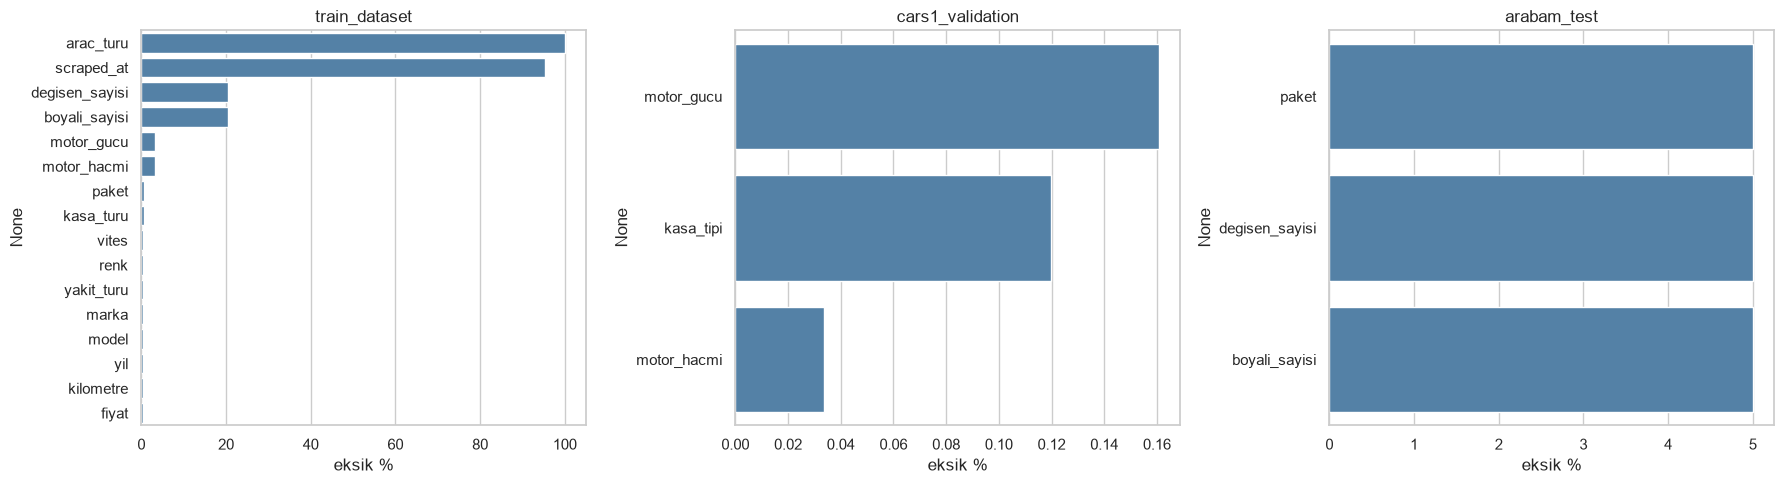

In [4]:
fig, axes = plt.subplots(1, len(SOURCES), figsize=(18, 5), sharey=False)
for ax, (name, df) in zip(axes, SOURCES.items()):
    missing = (df.isna().mean() * 100).sort_values(ascending=False)
    missing = missing[missing > 0]
    sns.barplot(x=missing.values, y=missing.index, ax=ax, color='steelblue')
    ax.set_title(name)
    ax.set_xlabel('eksik %')
plt.tight_layout()
plt.show()

## Madde 2 — Dağılım & outlier analizi

`fiyat`, `kilometre`, `yil`, `motor_hacmi`, `motor_gucu` için histogram/boxplot ve IQR tabanlı
aykırı değer sınırları (esas olarak `train_dataset` üzerinden, o eğitimde kullanılacak kaynak).

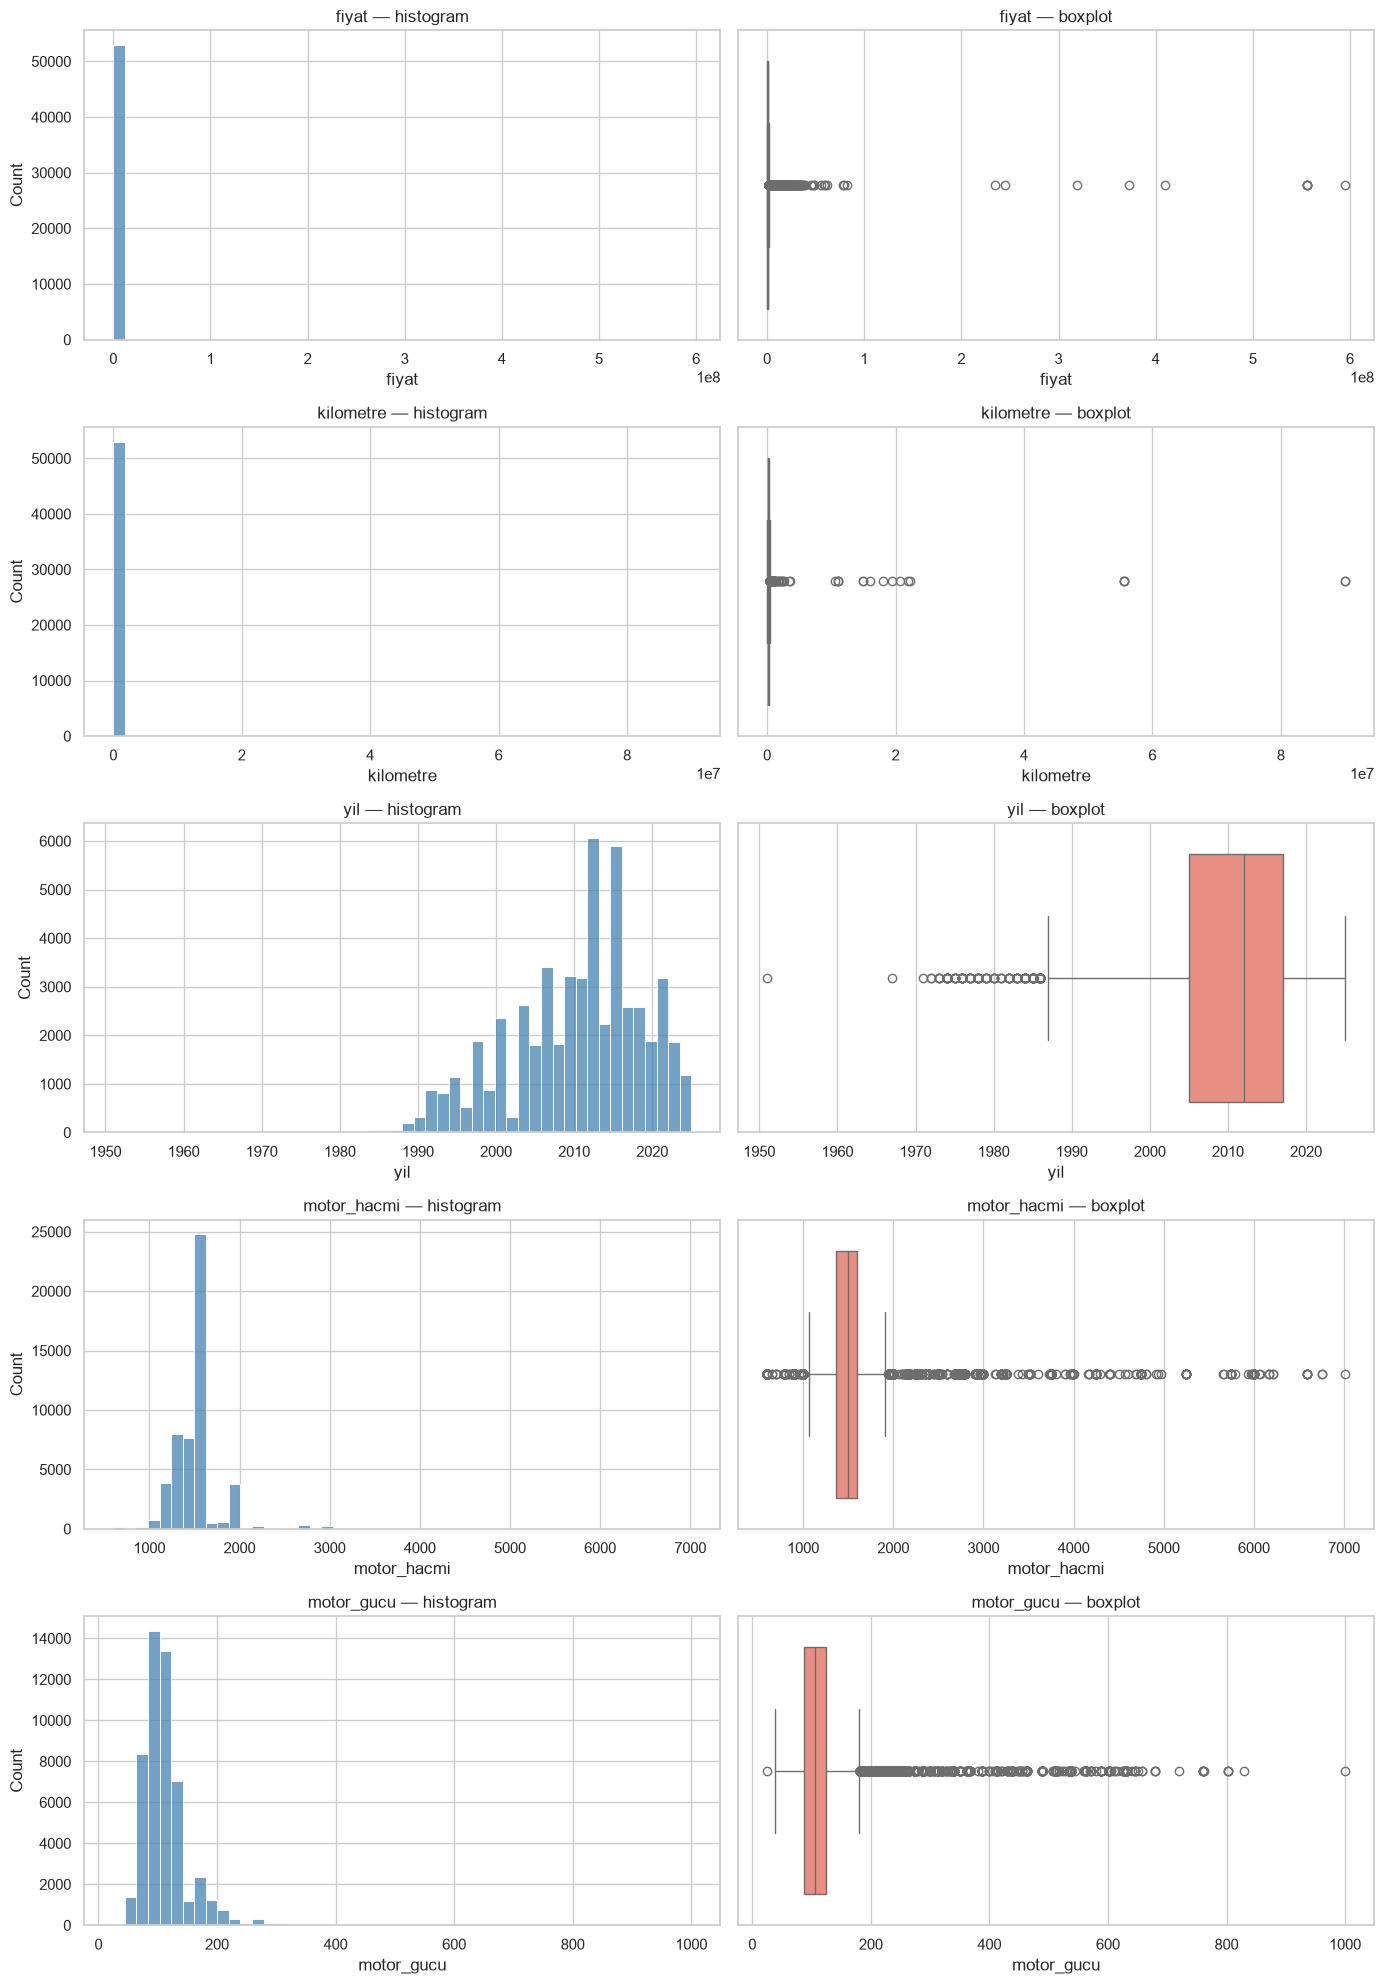

In [5]:
NUMERIC_FIELDS = ['fiyat', 'kilometre', 'yil', 'motor_hacmi', 'motor_gucu']
CURRENT_YEAR = 2026

train = SOURCES['train_dataset']

fig, axes = plt.subplots(len(NUMERIC_FIELDS), 2, figsize=(14, 4 * len(NUMERIC_FIELDS)))
for row, field in enumerate(NUMERIC_FIELDS):
    data = train[field].dropna()
    sns.histplot(data, ax=axes[row, 0], bins=50, color='steelblue')
    axes[row, 0].set_title(f'{field} — histogram')
    sns.boxplot(x=data, ax=axes[row, 1], color='salmon')
    axes[row, 1].set_title(f'{field} — boxplot')
plt.tight_layout()
plt.show()

In [6]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


rows = []
for field in NUMERIC_FIELDS:
    data = train[field].dropna()
    lo, hi = iqr_bounds(data)
    n_outliers = ((data < lo) | (data > hi)).sum()
    rows.append({
        'alan': field, 'min': data.min(), 'max': data.max(),
        'iqr_alt': round(lo, 1), 'iqr_ust': round(hi, 1),
        'iqr_disi_sayi': n_outliers, 'iqr_disi_%': round(100 * n_outliers / len(data), 2),
    })
display(pd.DataFrame(rows))

print('Mantiksal sinir kontrolleri (train_dataset):')
print('fiyat <= 0:', (train['fiyat'] <= 0).sum())
print(f'yil > {CURRENT_YEAR + 1}:', (train['yil'] > CURRENT_YEAR + 1).sum())
print('yil < 1950:', (train['yil'] < 1950).sum())
print('kilometre < 0:', (train['kilometre'] < 0).sum())
print('kilometre > 1_000_000:', (train['kilometre'] > 1_000_000).sum())

,alan,min,max,iqr_alt,iqr_ust,iqr_disi_sayi,iqr_disi_%
0,fiyat,10000.0,595000000.0,-632425.0,2027375.0,2713,5.11
1,kilometre,0.0,90000000.0,-95000.0,465000.0,492,0.93
2,yil,1951.0,2025.0,1987.0,2035.0,175,0.33
3,motor_hacmi,600.0,7011.0,1026.0,1938.0,4603,8.94
4,motor_gucu,25.0,1000.0,32.5,180.5,3414,6.63


Mantiksal sinir kontrolleri (train_dataset):
fiyat <= 0: 0
yil > 2027: 0
yil < 1950: 0
kilometre < 0: 0
kilometre > 1_000_000: 32


## Madde 3 — Kategorik alan dağılımları & korelasyonlar

`marka`/`yakit_turu`/`vites`/`kasa_turu` frekansları, fiyatla ilişkileri, sayısal alanlar arası korelasyon.

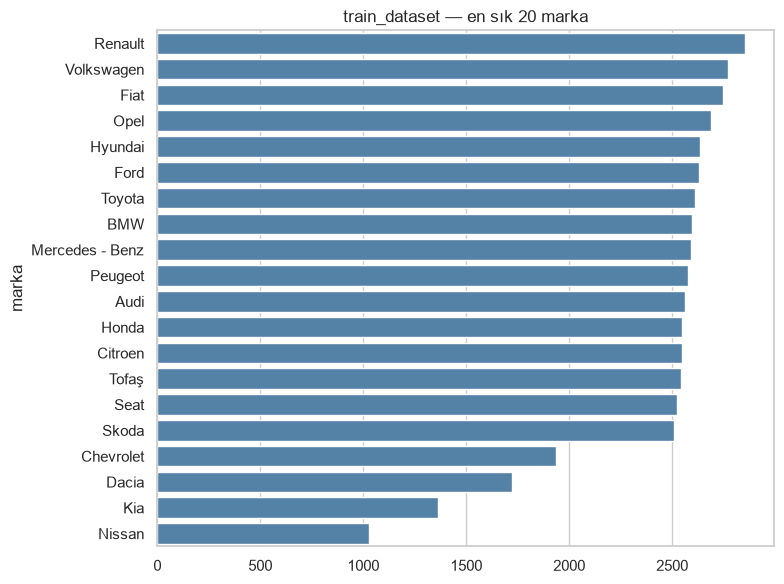

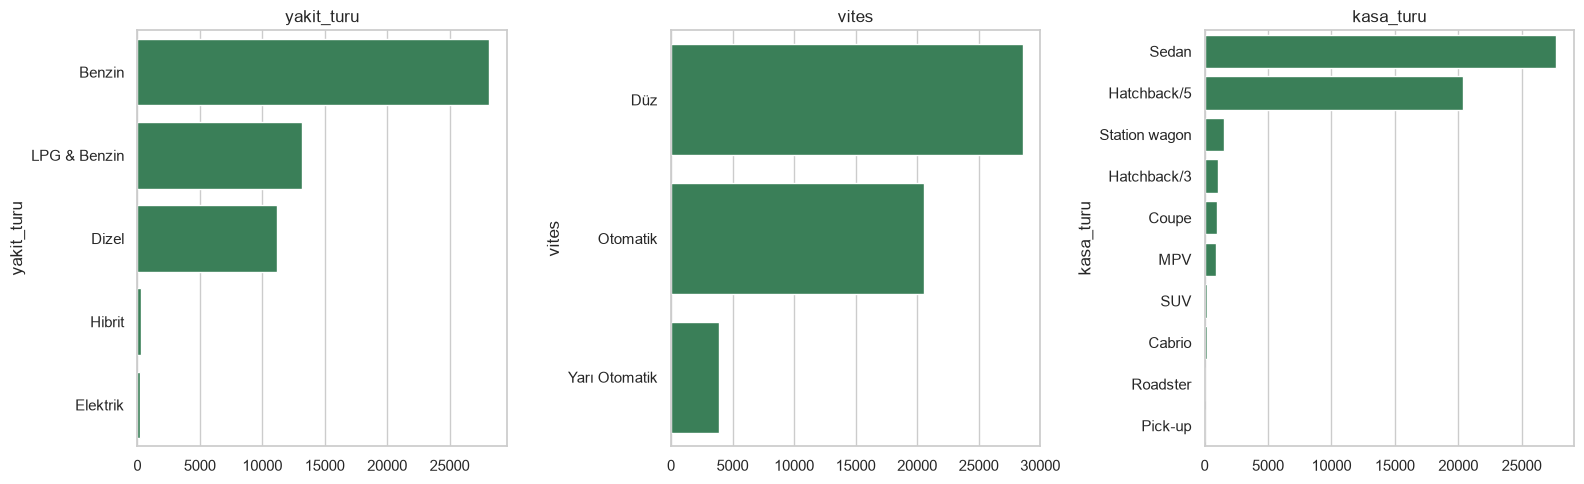

In [7]:
top_markalar = train['marka'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_markalar.values, y=top_markalar.index, ax=ax, color='steelblue')
ax.set_title('train_dataset — en sık 20 marka')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, field in zip(axes, ['yakit_turu', 'vites', 'kasa_turu']):
    counts = train[field].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax, color='seagreen')
    ax.set_title(field)
plt.tight_layout()
plt.show()

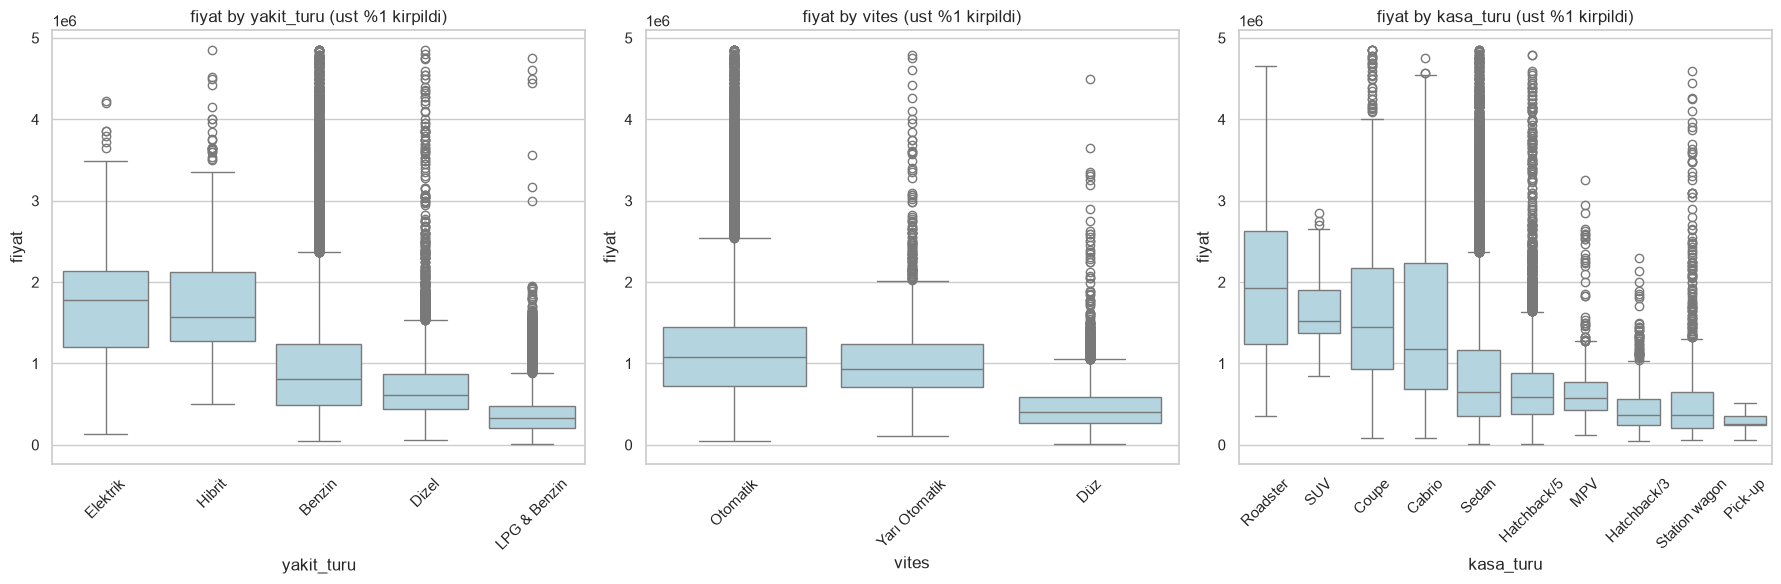

In [8]:
# Madde 2'de bulunan asiri fiyat uc degerleri (595M, 555.555.555 gibi) kutu grafigini
# okunmaz hale getiriyor; sadece gorsellestirme icin ust %1'i kirpiyoruz.
fiyat_p99 = train['fiyat'].quantile(0.99)
plot_df = train[train['fiyat'] <= fiyat_p99]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, field in zip(axes, ['yakit_turu', 'vites', 'kasa_turu']):
    order = plot_df.groupby(field)['fiyat'].median().sort_values(ascending=False).index
    sns.boxplot(data=plot_df, x=field, y='fiyat', ax=ax, order=order, color='lightblue')
    ax.set_title(f'fiyat by {field} (ust %1 kirpildi)')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

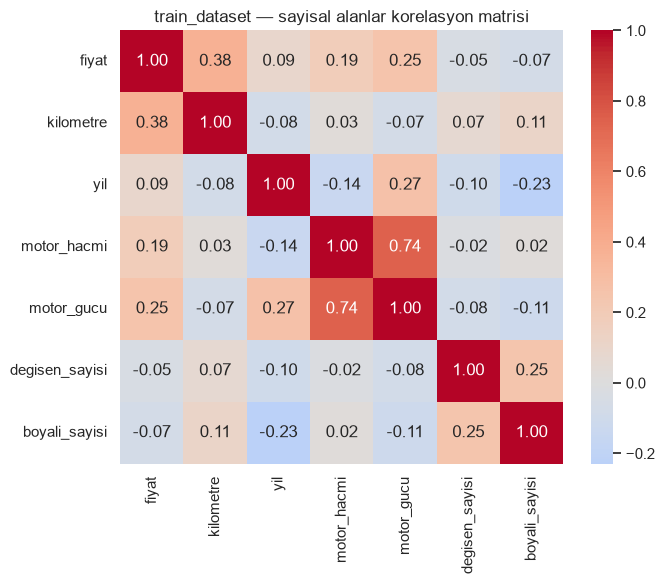

In [9]:
corr_fields = ['fiyat', 'kilometre', 'yil', 'motor_hacmi', 'motor_gucu', 'degisen_sayisi', 'boyali_sayisi']
corr = train[corr_fields].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('train_dataset — sayisal alanlar korelasyon matrisi')
plt.tight_layout()
plt.show()

## Madde 4 — Train vs validation dağılım karşılaştırması (distribution shift)

`train_dataset` (araba_bilgileri + arabalar) vs `cars1_validation` — aynı dağılımdan mı geliyorlar?

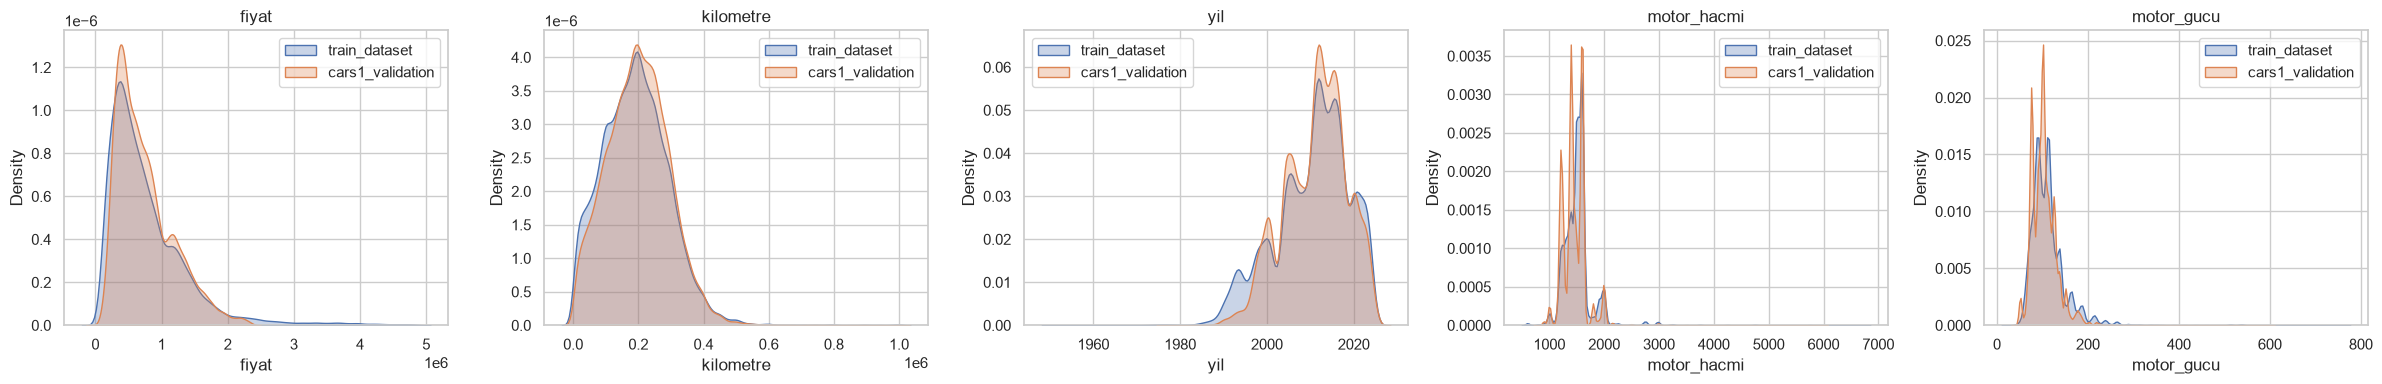

Medyan karsilastirmasi (kirpilmis):


,train_dataset,cars1_validation
fiyat,605000.0,640000.0
kilometre,189000.0,198000.0
yil,2012.0,2012.0
motor_hacmi,1500.0,1401.0
motor_gucu,105.0,101.0


In [10]:
val = SOURCES['cars1_validation'].rename(columns={'seri': 'model', 'vites_tipi': 'vites',
                                                    'yakit_tipi': 'yakit_turu', 'kasa_tipi': 'kasa_turu'})

# Karsilastirmayi anlamli kilmak icin ayni kirpma stratejisini (ust %1 fiyat, 1M km disi) iki tarafa da uygula.
train_c = train[(train['fiyat'] <= train['fiyat'].quantile(0.99)) & (train['kilometre'] <= 1_000_000)]
val_c = val[(val['fiyat'] <= val['fiyat'].quantile(0.99)) & (val['kilometre'] <= 1_000_000)]

fig, axes = plt.subplots(1, len(NUMERIC_FIELDS), figsize=(24, 4))
for ax, field in zip(axes, NUMERIC_FIELDS):
    sns.kdeplot(train_c[field].dropna(), ax=ax, label='train_dataset', fill=True, alpha=0.3)
    sns.kdeplot(val_c[field].dropna(), ax=ax, label='cars1_validation', fill=True, alpha=0.3)
    ax.set_title(field)
    ax.legend()
plt.tight_layout()
plt.show()

print('Medyan karsilastirmasi (kirpilmis):')
display(pd.DataFrame({
    'train_dataset': train_c[NUMERIC_FIELDS].median(),
    'cars1_validation': val_c[NUMERIC_FIELDS].median(),
}))

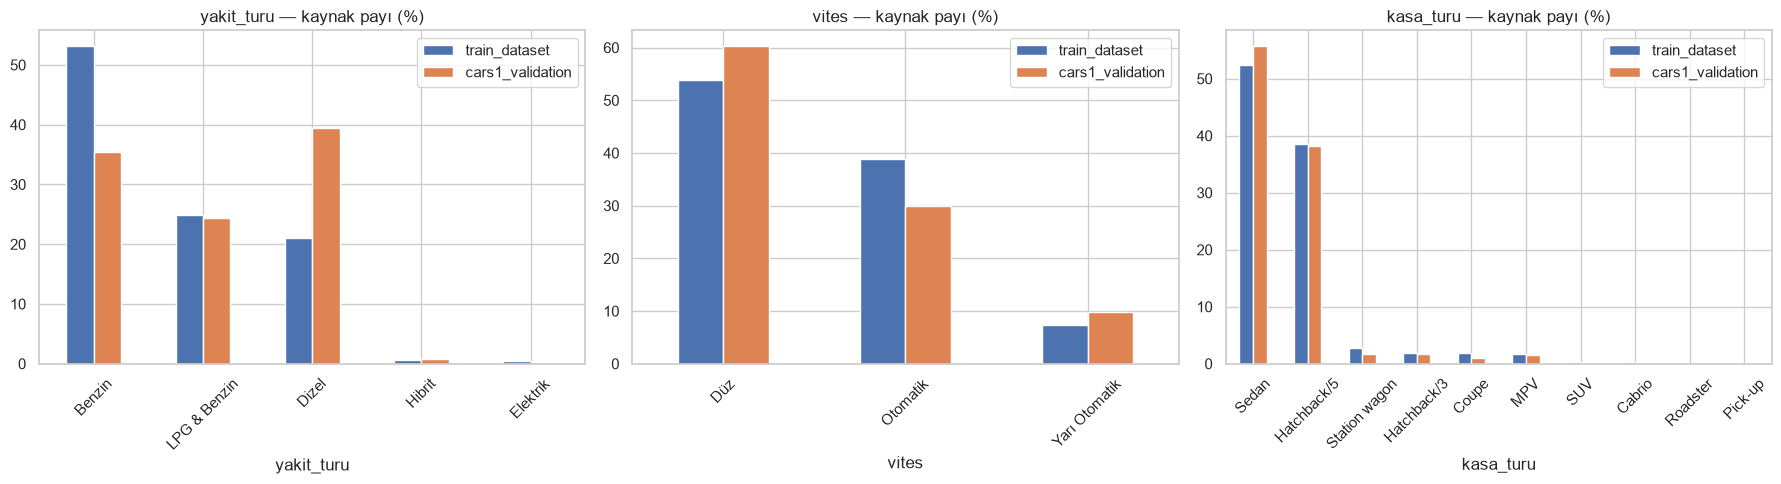

Ortak marka: 46 / train 76 / cars1 46
Ortak markalarin train_dataset kayitlarindaki payi: 99.0%


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, field in zip(axes, ['yakit_turu', 'vites', 'kasa_turu']):
    t = (train[field].value_counts(normalize=True) * 100).rename('train_dataset')
    v = (val[field].value_counts(normalize=True) * 100).rename('cars1_validation')
    comp = pd.concat([t, v], axis=1).fillna(0)
    comp.plot(kind='bar', ax=ax)
    ax.set_title(f'{field} — kaynak payı (%)')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

ortak_marka = set(train['marka'].dropna()) & set(val['marka'].dropna())
print(f'Ortak marka: {len(ortak_marka)} / train {train["marka"].nunique()} / cars1 {val["marka"].nunique()}')
print(f'Ortak markalarin train_dataset kayitlarindaki payi: '
      f'{100 * train["marka"].isin(ortak_marka).mean():.1f}%')

## Madde 5 — Feature engineering fikirleri & temizleme kararları

Madde 1-4 bulgularına dayanarak türetilmiş özellikleri (`yas`, `km_yil`) deneyip fiyatla
ilişkilerini ham `yil`/`kilometre` ile karşılaştırıyoruz; ardından kararları belgeliyoruz.

In [12]:
# Temizleme karari uygulanmis (Madde 2/3 bulgulari): ust %1 fiyat + 1M km disi kayitlar
# cikarilmis "temiz" bir kopya uzerinde turetilmis ozellikleri test ediyoruz.
clean = train[(train['fiyat'] <= train['fiyat'].quantile(0.99)) & (train['kilometre'] <= 1_000_000)].copy()
clean['yas'] = CURRENT_YEAR - clean['yil']
clean['km_yil'] = clean['kilometre'] / clean['yas'].replace(0, 1)

karsilastirma = clean[['fiyat', 'yil', 'yas', 'kilometre', 'km_yil']].corr()['fiyat']
print('Fiyat korelasyonu (temizlenmis veri):')
print(karsilastirma.round(3).drop('fiyat').to_string())

Fiyat korelasyonu (temizlenmis veri):
yil          0.631
yas         -0.631
kilometre   -0.445
km_yil       0.143


### Faz 8 — Kararlar Özeti (Faz 9/10 için girdi)

**Kullanılmayacak alanlar:**
- `arac_turu` — train_dataset'te %100 eksik, hiçbir zaman eğitim sinyali olamaz. Model özelliği olarak kullanılmayacak.
- `scraped_at` — train_dataset'te %95.4 eksik, zaman bazlı özellik (`ilan yaşı` vb.) türetmek için güvenilmez. Kullanılmayacak.

**Outlier temizleme stratejisi (train_dataset üzerinde, eğitim öncesi uygulanacak):**
- `fiyat`: üst %1'i (≈530 kayıt) çıkar — Madde 2'de bulunan 595M TL ve tekrarlayan `555.555.555 TL` gibi sahte/placeholder fiyatlar bu dilimde.
- `kilometre`: 1.000.000 km üstü 32 kayıt çıkar — fiziksel olarak anlamsız (muhtemelen veri girişi hatası).
- Bu iki filtre uygulanınca `kilometre`-`fiyat` korelasyonu +0.38 (yanıltıcı) → **-0.45**'e (beklenen yön) dönüyor — filtrenin gerekliliği doğrulandı (Madde 3).

**Türetilmiş özellikler (feature engineering):**
- `yas = 2026 - yil`: ham `yil` ile aynı bilgiyi taşır ama model için daha sezgisel; korelasyon yönü ham `yil`'in negatifi.
- `km_yil = kilometre / yas`: kullanım yoğunluğunu ham kilometreden daha iyi yakalayabilir, model kurulumunda (Faz 10) denenmeli.
- Korelasyon büyüklükleri yukarıdaki hücrede raporlanıyor; nihai özellik seçimi Faz 9 baseline sonrası netleşecek.

**Eksik değer stratejisi:**
- `degisen_sayisi`/`boyali_sayisi` (%20.5 eksik): `NaN` "bilinmiyor" anlamına geliyor (Faz 6 kararı) — 0 ile doldurmak yanlış sinyal verir (sanki hasarsız gibi). Ayrı bir "bilinmiyor" kategorisi/flag ile modele taşınmalı, 0'a doldurulmamalı.
- `motor_hacmi`/`motor_gucu` (%3.2 eksik), `marka`/`model`/`yakit_turu`/`vites` (%0.3-0.5 eksik): satır sayısı görece küçük, medyan/mod ile doldurma ya da satır çıkarma Faz 9'da denenebilir.

**Kategorik encoding planı:**
- `yakit_turu`, `vites`, `kasa_turu` (düşük kardinalite, ≤12 değer): one-hot encoding yeterli.
- `marka` (76 değer), `model` (543 değer): one-hot patlar — frekans/target encoding ya da ağaç tabanlı modellerde (XGBoost/LightGBM) doğrudan kategori desteği tercih edilmeli.

**Cross-source doğrulama (Madde 4):** `train_dataset` ve `cars1_validation` medyanları tüm sayısal alanlarda ~%5-7 fark içinde, marka kapsamı %99 örtüşüyor — ciddi bir distribution shift yok, Faz 11'deki cross-source değerlendirme güvenilir olacak.